In [2]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers import Kusiak2022

In [2]:
importlib.reload(Kusiak2022)

Kusiak2022.Table4().df

Sample,sigmalogM,alphas,logMHODmin,logMHOD1,labda,107ASN,MHODmin,M1,M,bg,alphasat,chi2,PTE
Sample,,,,,,,,,,,,,
Blue,0.687,1.304,11.796,12.701,1.087,-0.255,6.250000e+11,5.030000e+12,1.880000e+13,1.49,0.30,11.8,0.544
Green,0.973,1.302,13.128,13.441,2.746,1.379,1.340000e+11,2.760000e+13,1.660000e+13,2.01,0.16,7.9,0.850
Red,0.403,1.629,12.707,13.519,0.184,28.748,5.100000e+12,3.300000e+13,1.550000e+13,2.98,0.14,15.3,0.289


In [3]:
importlib.reload(Kusiak2022)

Kusiak2022.Table5().df

Sample,sigmalogM,alphas,logMHODmin,logMHOD1,labda,107ASN,MHODmin,M1,Mh,bg,alphasat
Sample,,,,,,,,,,,
Blue,0.73,1.38,12.11,13.00,1.11,-0.16,1.830000e+12,1.130000e+13,1.810000e+13,1.50,0.23
Green,0.61,1.23,12.39,12.87,2.50,1.35,5.220000e+12,1.180000e+13,1.640000e+13,2.05,0.38
Red,0.75,1.18,13.23,13.20,1.30,27.95,6.600000e+13,1.230000e+14,1.520000e+13,2.92,0.36


In [ ]:
importlib.reload(Kusiak2022)

fig, axs = Kusiak2022.Fig9().full()

axs = axs.flatten()
logMh = np.linspace(11, 15.9, 50)

colors = ['cyan', 'lime', 'magenta']
for i, sample in enumerate(['Blue', 'Green', 'Red']):
    K22 = Kusiak2022.HOD({'sample':sample})
    axs[0].scatter(10**logMh/K22.h, K22.Ncen(logMh)(), marker='X', c=colors[i], label='Nc')
    axs[0].scatter(10**logMh/K22.h, K22.Nsat(logMh)(), c=colors[i], label='Ns')
    axs[i+1].scatter(10**logMh/K22.h, K22.Ncen(logMh)(), marker='X', c=colors[i], label='Nc')
    axs[i+1].scatter(10**logMh/K22.h, K22.Nsat(logMh)(), c=colors[i], label='Ns')

axs[0].legend(); axs[1].legend(); axs[2].legend(); axs[3].legend()
axs[1].set(title='Blue Sample'); axs[2].set(title='Green Sample'); axs[3].set(title='Red Sample')
plt.show()

In [ ]:
importlib.reload(Kusiak2022)
fig, ax = Kusiak2022.Fig2().full()

for subsamp, color in zip(['Blue', 'Green', 'Red'], ['b', 'g', 'r']):
    K22 = Kusiak2022.TargetData({'sample':subsamp})
    K22.make_zdists()
    ax.scatter(K22.z, K22.dNdz_norm, c=color, marker='x', alpha=0.7, label=subsamp)

ax.legend(loc='lower right')
plt.show()

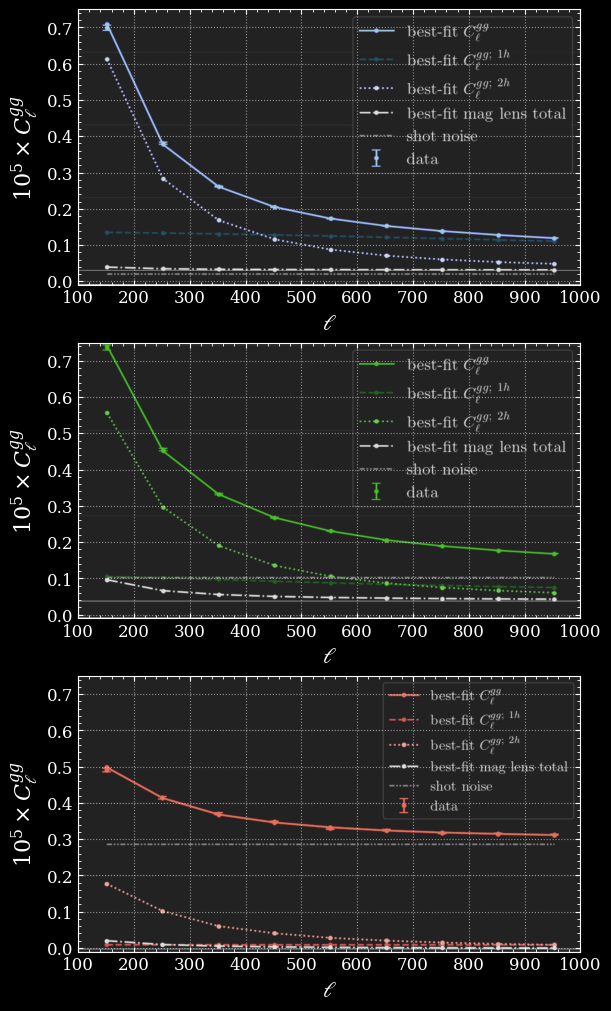

In [12]:
importlib.reload(Kusiak2022)

fig, axs = Kusiak2022.Fig8_col1().full()

In [ ]:
importlib.reload(Kusiak2022)
fig, axs = Kusiak2022.Fig15().full()


from Models import HaloModels
importlib.reload(HaloModels)

hmod = HaloModels.colossus_model(**Kusiak2022.HOD().info)

ks = np.geomspace(1e-2, 1e2) * u.dimensionless_unscaled

z, logMh = 0.5, np.log10(3e14/Kusiak2022.HOD().h)
c200c0, ells0 = 3.4, ks*(1317/Kusiak2022.HOD().h)-0.5
ells = ks/u.Mpc*hmod.chi(z)-0.5
r200c = hmod.rdel('200c')(z, logMh).value
prefac = 10**logMh*u.Msun/hmod.rhom(0)

K22 = Kusiak2022.HOD({'sample':'Blue'}, rhom=hmod.rhom, r200c=hmod.rdel('200c'), c200c=hmod.c)
axs[0].scatter(ells, K22.nsat(ks, z, logMh)({'Lambda':1.5/r200c})[:, 0, 0]/prefac, color='cyan', alpha=0.5, label=r'$\lambda R_{200c}=1.5$')
axs[0].scatter(ells, K22.nsat(ks, z, logMh)({'Lambda':1/r200c})[:, 0, 0]/prefac, color='lime', alpha=0.5, label=r'$\lambda R_{200c}=1$')
axs[0].scatter(ells, K22.nsat(ks, z, logMh)({'Lambda':0.5/r200c})[:, 0, 0]/prefac, color='magenta', alpha=0.5, label=r'$\lambda R_{200c}=0.5$')

axs[0].legend(loc='lower left')
plt.show()